<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">
  <img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExbmhqeWs3OTFqMmpsdnF2ejdjZmprZmFoNHlscHRldm1zNzhrZGF2bCZlcD12MV9naWZzX3NlYXJjaCZjdD1n/l1KdbHUPe27GQsJH2/giphy.gif" alt="Reinforced concrete design animation" width="700" style="max-width:100%; border-radius:10px;">
  <h3 style="color:#ffffff; margin:15px 0 8px 0;"><b>Introduction to Reinforced Concrete Design II</b></h3>
  <p style="margin:4px 0;"><b>Authors:</b> Msc. Ing. Carlos Andrés Celi Sánchez · Nicolás Mora Bowen · Juan Sebastián Baquero</p>
  <p style="margin:4px 0;"><b>Course:</b> Reinforced Concrete Design II</p>
  <p style="margin:4px 0; color:#d1d5db;">Basic Coding.</p>
</div>

### Libraries

> **Why these libraries?**
> - `numpy` (`np`): fast numerics and linear algebra on arrays -- the workhorse of engineering math.
> - `pandas` (`pd`): tabular data (DataFrames) -- think of a spreadsheet you can code with.
> - `matplotlib.pyplot` (`plt`): 2D plotting -- turning numbers into figures.
> - We load them once at the top; every cell below can then use `np`, `pd` and `plt`.

In [1]:
import numpy as np               # Import the NumPy library
import pandas as pd              # Import the pandas library
import matplotlib.pyplot as plt  # Import pyplot to create figures

#### Core

In [2]:
from repo__CORE_concreteII_desing import *

### Basic Operations

> **What we are doing here**
> Simple arithmetic, plus wrapping a Python value into a *pandas DataFrame* to view it as a table.
> - `a` is a plain Python number.
> - `pd.DataFrame([a], columns=['value'])` builds a one-row, one-column table.
> - We can print to the console **and** let the last line of a cell render as a nice table.

#### Aritmetic

In [3]:
a = np.sum(2 + 3)                            # Calculate the sum of 2 and 3
a_df = pd.DataFrame([a], columns=['value'])  # Create a DataFrame with the calculated value

print('=' * 80)                              # Print a separator line
print(f'The value of a = {a}')               # Display the calculated value of a
print('=' * 80)                              # Print a separator line

The value of a = 5


In [4]:
a_df  # Display the DataFrame

,value
0,5


#### Basic Arrays

> **One-dimensional vs two-dimensional arrays**
> - `b` is a 1D array: a row of 5 numbers -- later this is how we store story displacements, forces, etc.
> - `c` is a 2D array with 5 rows x 2 columns, handy for (level, value) pairs.
> - DataFrames add table **headers**, which make results readable for reports.

In [5]:
b = np.array([1, 2, 3, 4, 5])              # Create a one-dimensional NumPy array
c = np.array(                              # Create a two-dimensional NumPy array
    [
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10]
    ]
)
b_df = pd.DataFrame(b, columns=['value'])  # Convert array b into a DataFrame
c_df = pd.DataFrame(                       # Convert array c into a DataFrame
    c,
    columns=['value 1', 'value 2']
)

print('=' * 80)                            # Print a separator line
print(f'The value of array b = {b}')       # Display the values of array b
print(f'The value of array c =\n{c}')      # Display the values of array c
print('=' * 80)                            # Print a separator line

c_df.head(len(c_df))                       # Display all rows of DataFrame c

The value of array b = [1 2 3 4 5]
The value of array c =
[[ 1  6]
 [ 2  7]
 [ 3  8]
 [ 4  9]
 [ 5 10]]


,value 1,value 2
0,1,6
1,2,7
2,3,8
3,4,9
4,5,10


#### Basic "for"

> **Very basic `for` loop**
> - `np.arange(1, 5 + 1, 1)` generates the sequence 1, 2, 3, 4, 5 (from 1 up to 6, stepping by 1).
> - The loop repeats its indented body once per value of `i`, appending each `i` to the list `b`.
> - Note `5 + 1`: the upper limit of `np.arange` is *exclusive*, so we add 1 to include 5.

In [6]:
b = []                                     # Start with an empty list

for i in np.arange(1, 5 + 1, 1):           # Loop i from 1 to 5 (the upper limit is exclusive)
    b.append(i)  # Append the current value of i to the list b

print('=' * 80)                            # Print a separator line
print(f'The value of array b = {b}')       # Display the values of array b
print('=' * 80)                            # Print a separator line

b_df = pd.DataFrame(b, columns=['value'])  # Convert array b into a DataFrame
b_df.head(len(b_df))                       # Display all rows of DataFrame b

The value of array b = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,value
0,1
1,2
2,3
3,4
4,5


$$
x(t) = x_0 \cos(\omega t) + \frac{\dot{x}_0}{\omega}\sin(\omega t)
$$

> **A bit of physics before we code**
> `x(t)` is the free response of an undamped single-degree-of-freedom (SDOF) oscillator:
> - `x0` = initial displacement, `xdot0` = initial velocity, `omega` = natural frequency.
> - We will evaluate this analytical solution at many time steps -- a small taste of structural dynamics.

* Data

> **Problem data**
> - `xo`: initial displacement [m], `xvo`: initial velocity [m/s], `w`: natural frequency [rad/s].
> - `to`: start time [s], `tf`: end time [s], `dt`: time step [s] (0.01 s -> 500 steps).
> - Units are up to us: the math works the same for any consistent unit system.

In [7]:
xo = 3     # Initial displacement [m]
xvo = 0    # Initial velocity [m/s]
w = 5      # Natural frequency [rad/s]
to = 0     # Start time [s]
dt = 0.01  # Time step [s]
tf = 5     # End time [s]

* Solution

> **Solution loop**
> - We loop `t` from `to` to `tf` in steps of `dt`, appending the analytical solution `x(t)` and each time `t`.
> - Same pattern as the "basic for" cell, now applied to a real equation.
> - `x_df` stores the displacements so we can inspect the first rows of the table.

In [8]:
x = []                                            # Store the displacement at each time step
ti = []                                           # Store the time values

for t in np.arange(to, tf + dt, dt):              # Loop over all time steps
    x.append(xo * np.cos(w*t) + xvo / w * np.sin(w*t))  # Evaluate the analytical solution
    ti.append(t)                                        # Append the current time value

print('=' * 80)                                   # Print a separator line
print(f'The value of array x = {x}')              # Display the displacement array
print(f'The value of array t = {ti}')             # Display the time array
print('=' * 80)                                   # Print a separator line

x_df = pd.DataFrame(x, columns=['Displacement'])  # Build a DataFrame from the results
x_df.head(10)                                     # Show the first 10 rows

The value of array x = [np.float64(3.0), np.float64(2.996250781184899), np.float64(2.9850124958340776), np.float64(2.9663132338081266), np.float64(2.940199733523725), np.float64(2.9067372651319343), np.float64(2.866009467376818), np.float64(2.8181181385421366), np.float64(2.7631829820086553), np.float64(2.7013413070580308), np.float64(2.6327476856711183), np.float64(2.557573566178517), np.float64(2.476006844729035), np.float64(2.388251395647168), np.float64(2.2945265618534654), np.float64(2.1950666066214626), np.float64(2.0901201280414963), np.float64(1.9799494376549462), np.float64(1.8648299048119936), np.float64(1.7450492683916508), np.float64(1.6209069176044193), np.float64(1.4927131436751808), np.float64(1.360788364276732), np.float64(1.2254623226524715), np.float64(1.0870732634300209), np.float64(0.945967087185806), np.float64(0.802496485873762), np.float64(0.6570200612791245), np.float64(0.5099014287007224), np.float64(0.3615083081020999), np.float64(0.2122116050031087), np.float

,Displacement
0,3.000000
1,2.996251
2,2.985012
3,2.966313
4,2.940200
5,2.906737
6,2.866009
7,2.818118
8,2.763183
9,2.701341


#### Basic Plot

> **First figure**
> - `fig, ax = plt.subplots(1,1, figsize=(15,6))` creates a figure with one axes.
> - This cell **reuses** `ti` and `x` computed above -- run it after the Solution cell or it will fail.
> - `ax.plot(...)` draws the curve; `ax.set_*` controls title, labels and limits.

(0.0, 5.0)

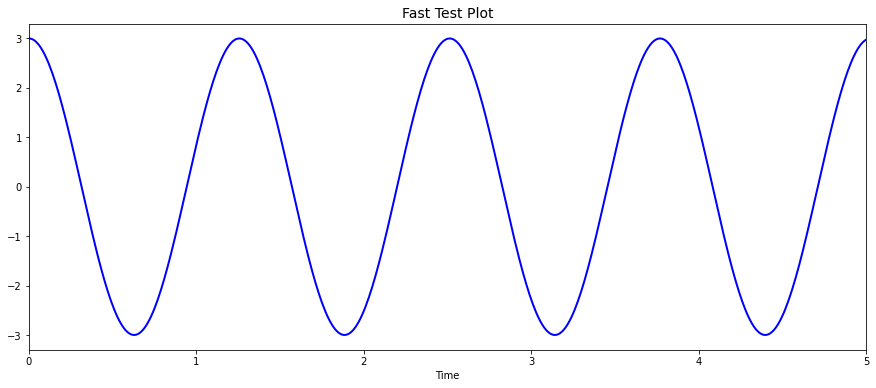

In [9]:
# This cell reuses `ti` and `x` from the Solution cell (notebook cells share state)
fig, ax = plt.subplots(1,1, figsize = (15,6))                                      # Create a figure with one subplot
ax.plot(ti,x, ls = '-', lw = 2, color = (0,0,1), label = 'Response Displacement')  # Draw the curve
ax.set_title('Fast Test Plot', color = (0,0,0), fontsize = 14)                     # Add a title
ax.set_xlabel('Time')                                                              # Label the x axis
ax.set_xlim(to,tf)                                                                 # Show the full time window

#### Basic Methods (fuction's)

> **From script to function**
> - A *function* packages the plotting code so we can reuse it with any `x, y`.
> - `np.min(x)` / `np.max(x)` set sensible axis limits automatically.
> - Didactic note: using `any` as a default value is not standard practice (we keep it unchanged here); in real code use `None` plus a check.
> - The following cell calls `SimplePlot` with a smooth curve built with `np.linspace`.

In [10]:
def SimplePlot(x = any,y = any, title = 'test', xlabel = 'x', ylabel = 'y'):
    fig, ax = plt.subplots(1,1, figsize = (15,6))                   # Create a figure with one subplot
    ax.plot(x,y, ls = '-', lw = 2, color = (0,0,1), label = title)  # Draw the curve using the input title as label
    ax.set_title(title, color = (0,0,0), fontsize = 14)             # Title taken from the argument
    ax.set_xlabel(xlabel)                                           # X axis label from the argument
    ax.set_ylabel(ylabel)                                           # Y axis label from the argument
    ax.set_xlim(np.min(x),np.max(x))                                # Axis limits computed from the data
    plt.show()                                                      # Render the figure

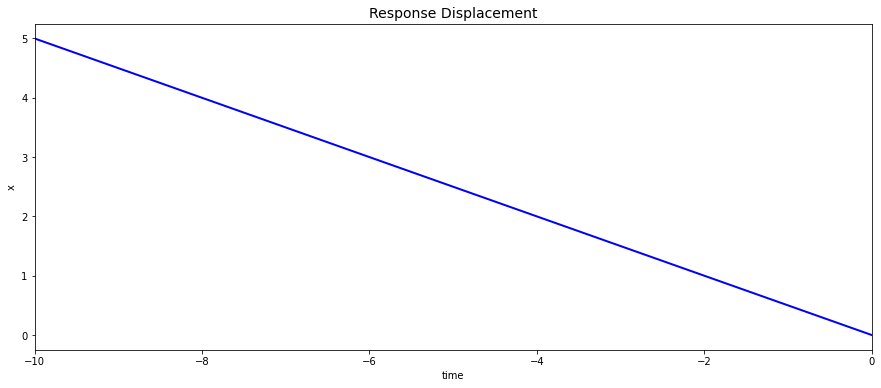

In [11]:
yy = np.linspace(0,5,500)                                                        # Build 500 y values between 0 and 5
xx = np.linspace(0,-10,500)                                                      # Build 500 x values between 0 and -10

SimplePlot(xx, yy, title= 'Response Displacement', xlabel= 'time', ylabel= 'x')  # Call the function with the new data

#### Simple Class

> **From function to class**
> - A *class* groups data (attributes stored in `__init__` with `self.`) together with methods that use that data.
> - `pepito = SimpleClass(xx, yy)` creates an instance that stores `xx` and `yy`.
> - `pepito.SimplePlot()` draws it -- the method reads the values from the instance via `self.x`, `self.y`.
> - This is the object-oriented pattern we will later use to build the real design tools.

In [12]:
# class SimpleClass():
#     def __init__(self, x = any,y = any, title = 'test', xlabel = 'x', ylabel = 'y'):
#         self.x = x                                                      # Store x in the instance
#         self.y = y                                                      # Store y in the instance
#         self.title = title                                              # Store the title
#         self.xlabel = xlabel                                            # Store the x label
#         self.ylabel = ylabel                                            # Store the y label

#     def SimplePlot(self):
#         x = self.x                                                      # Read x from the instance
#         y = self.y                                                      # Read y from the instance
#         title = self.title                                              # Read the title
#         xlabel = self.xlabel                                            # Read the x label
#         ylabel = self.ylabel                                            # Read the y label

#         fig, ax = plt.subplots(1,1, figsize = (15,6))                   # Create a figure with one subplot
#         ax.plot(x,y, ls = '-', lw = 2, color = (0,0,1), label = title)  # Draw the curve
#         ax.set_title(title, color = (0,0,0), fontsize = 14)             # Add a title
#         ax.set_xlabel(xlabel)                                           # Label the x axis
#         ax.set_ylabel(ylabel)                                           # Label the y axis
#         ax.set_xlim(np.min(x),np.max(x))                                # Axis limits computed from the data
#         plt.show()                                                      # Render the figure

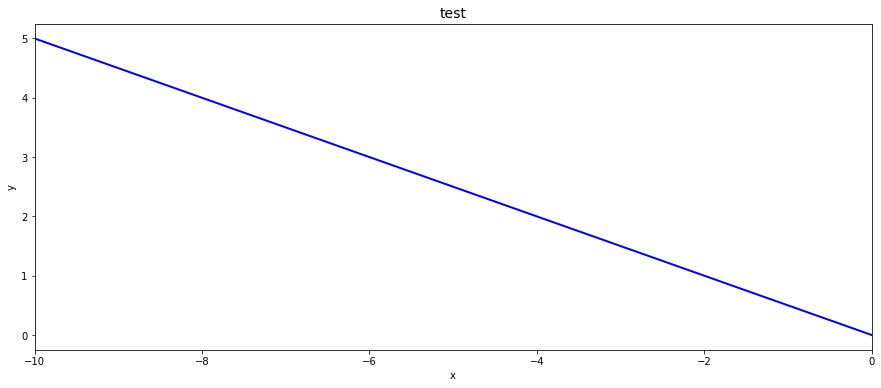

In [13]:
pepito = SimpleClass(xx,yy)  # Create an instance storing our arrays
pepito.SimplePlot()          # Plot it with the class method